In [1]:
# Primjena grafova u modelovanju društvenih mreža

## Implementacija strukture grafa i analiza veza pomoću BFS i DFS algoritama

#Autor: Nikolina Gordić 25/020
#Predmet: Strukture podataka i algoritmi


!pip install networkx matplotlib --quiet

from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

print("Biblioteke su uspješno učitane.")

Biblioteke su uspješno učitane.


In [2]:
## Implementacija strukture grafa


class SocialNetworkGraph:
    def __init__(self):
        self.graph = {}

    def add_user(self, user):
        if user not in self.graph:
            self.graph[user] = set()

    def add_connection(self, user1, user2):
        self.add_user(user1)
        self.add_user(user2)

        self.graph[user1].add(user2)
        self.graph[user2].add(user1)

    def remove_connection(self, user1, user2):
        if user1 in self.graph and user2 in self.graph:
            self.graph[user1].discard(user2)
            self.graph[user2].discard(user1)

    def display_network(self):
        for user, friends in self.graph.items():
            print(f"{user}: {', '.join(sorted(friends))}")

In [3]:
## BFS algoritam (Breadth-First Search)

def bfs_shortest_path(self, start, target):
    if start not in self.graph or target not in self.graph:
        return None

    queue = deque([[start]])
    visited = {start}

    while queue:
        path = queue.popleft()
        current = path[-1]

        if current == target:
            return path

        for neighbor in self.graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return None

SocialNetworkGraph.bfs_shortest_path = bfs_shortest_path

In [5]:
## DFS algoritam (Depth-First Search)

def dfs_traversal(self, start):
    if start not in self.graph:
        return []

    visited = set()
    result = []

    def dfs(user):
        visited.add(user)
        result.append(user)

        for neighbor in sorted(self.graph[user]):
            if neighbor not in visited:
                dfs(neighbor)

    dfs(start)
    return result

SocialNetworkGraph.dfs_traversal = dfs_traversal

In [6]:
## Analiza društvene mreže

def number_of_connections(self):
    return {user: len(friends) for user, friends in self.graph.items()}


def most_connected_user(self):
    if not self.graph:
        return None

    connections = self.number_of_connections()
    max_connections = max(connections.values())

    return [
        user for user, count in connections.items()
        if count == max_connections
    ], max_connections


def connected_components(self):
    visited = set()
    components = []

    for user in sorted(self.graph):
        if user not in visited:
            component = []
            stack = [user]
            visited.add(user)

            while stack:
                current = stack.pop()
                component.append(current)

                for neighbor in sorted(self.graph[current]):
                    if neighbor not in visited:
                        visited.add(neighbor)
                        stack.append(neighbor)

            components.append(sorted(component))

    return components


SocialNetworkGraph.number_of_connections = number_of_connections
SocialNetworkGraph.most_connected_user = most_connected_user
SocialNetworkGraph.connected_components = connected_components

In [7]:
## Kreiranje testne društvene mreže


network = SocialNetworkGraph()

connections = [
    ("Ana", "Marko"),
    ("Ana", "Sara"),
    ("Marko", "Ivan"),
    ("Marko", "Jelena"),
    ("Sara", "Petar"),
    ("Sara", "Marija"),
    ("Ivan", "Nikola"),
    ("Jelena", "Nikola"),
    ("Petar", "Luka"),
    ("Marija", "Luka"),
    ("Nikola", "Teodora"),
    ("Luka", "Teodora"),

    ("Milica", "Stefan"),
    ("Stefan", "Andrej"),
    ("Andrej", "Katarina")
]

for user1, user2 in connections:
    network.add_connection(user1, user2)

print("Društvena mreža je uspješno kreirana.")
print()
network.display_network()

Društvena mreža je uspješno kreirana.

Ana: Marko, Sara
Marko: Ana, Ivan, Jelena
Sara: Ana, Marija, Petar
Ivan: Marko, Nikola
Jelena: Marko, Nikola
Petar: Luka, Sara
Marija: Luka, Sara
Nikola: Ivan, Jelena, Teodora
Luka: Marija, Petar, Teodora
Teodora: Luka, Nikola
Milica: Stefan
Stefan: Andrej, Milica
Andrej: Katarina, Stefan
Katarina: Andrej


In [8]:
## Testiranje BFS i DFS algoritama


print("=== BFS - Najkraći put ===")
path = network.bfs_shortest_path("Ana", "Teodora")
print("Najkraći put od Ane do Teodore:")
print(" -> ".join(path))

print("\n=== DFS - Obilazak mreže ===")
dfs_result = network.dfs_traversal("Ana")
print(dfs_result)

print("\n=== Broj prijatelja po korisniku ===")
for user, count in network.number_of_connections().items():
    print(f"{user}: {count}")

print("\n=== Najpovezaniji korisnik ===")
users, count = network.most_connected_user()
print(f"Korisnik(ici): {', '.join(users)}")
print(f"Broj veza: {count}")

print("\n=== Povezane komponente ===")
components = network.connected_components()

for i, component in enumerate(components, start=1):
    print(f"Komponenta {i}: {component}")

=== BFS - Najkraći put ===
Najkraći put od Ane do Teodore:
Ana -> Marko -> Jelena -> Nikola -> Teodora

=== DFS - Obilazak mreže ===
['Ana', 'Marko', 'Ivan', 'Nikola', 'Jelena', 'Teodora', 'Luka', 'Marija', 'Sara', 'Petar']

=== Broj prijatelja po korisniku ===
Ana: 2
Marko: 3
Sara: 3
Ivan: 2
Jelena: 2
Petar: 2
Marija: 2
Nikola: 3
Luka: 3
Teodora: 2
Milica: 1
Stefan: 2
Andrej: 2
Katarina: 1

=== Najpovezaniji korisnik ===
Korisnik(ici): Marko, Sara, Nikola, Luka
Broj veza: 3

=== Povezane komponente ===
Komponenta 1: ['Ana', 'Ivan', 'Jelena', 'Luka', 'Marija', 'Marko', 'Nikola', 'Petar', 'Sara', 'Teodora']
Komponenta 2: ['Andrej', 'Katarina', 'Milica', 'Stefan']


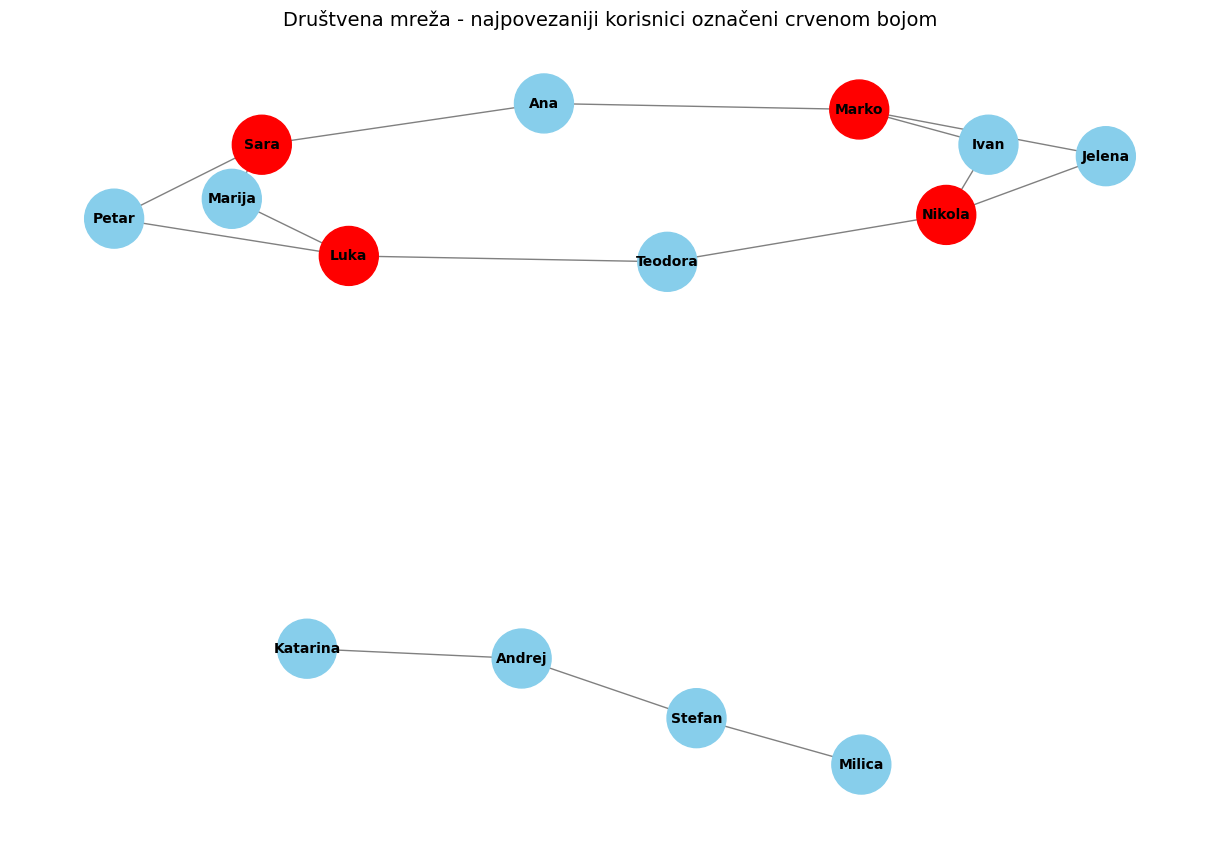

In [10]:
## Vizualizacija društvene mreže


def visualize_network_advanced(self):
    G = nx.Graph()

    for user in self.graph:
        G.add_node(user)

    for user, friends in self.graph.items():
        for friend in friends:
            G.add_edge(user, friend)

    top_users, _ = self.most_connected_user()

    node_colors = []

    for node in G.nodes():
        if node in top_users:
            node_colors.append("red")
        else:
            node_colors.append("skyblue")

    plt.figure(figsize=(12, 8))

    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=node_colors,
        node_size=1800,
        font_size=10,
        font_weight="bold",
        edge_color="gray"
    )

    plt.title(
        "Društvena mreža - najpovezaniji korisnici označeni crvenom bojom",
        fontsize=14
    )

    plt.show()


SocialNetworkGraph.visualize_network_advanced = visualize_network_advanced

network.visualize_network_advanced()

In [11]:
## Preporuka prijatelja


def friend_recommendations(self, user):
    if user not in self.graph:
        return {}

    recommendations = {}

    for friend in self.graph[user]:
        for mutual in self.graph[friend]:

            if mutual != user and mutual not in self.graph[user]:

                recommendations[mutual] = (
                    recommendations.get(mutual, 0) + 1
                )

    return dict(
        sorted(
            recommendations.items(),
            key=lambda x: x[1],
            reverse=True
        )
    )


SocialNetworkGraph.friend_recommendations = friend_recommendations

In [12]:
print("=== Preporuke prijatelja za Anu ===")

recommendations = network.friend_recommendations("Ana")

for user, mutual_count in recommendations.items():
    print(
        f"{user} - broj zajedničkih prijatelja: {mutual_count}"
    )

=== Preporuke prijatelja za Anu ===
Jelena - broj zajedničkih prijatelja: 1
Ivan - broj zajedničkih prijatelja: 1
Marija - broj zajedničkih prijatelja: 1
Petar - broj zajedničkih prijatelja: 1


In [13]:
## Završni izvještaj


print("=" * 60)
print("PROJEKAT: MODELOVANJE DRUŠTVENE MREŽE POMOĆU GRAFA")
print("=" * 60)

print("\n1. Prikaz društvene mreže:")
network.display_network()

print("\n2. BFS - najkraći put između Ane i Teodore:")
path = network.bfs_shortest_path("Ana", "Teodora")
print(" -> ".join(path) if path else "Put ne postoji.")

print("\n3. DFS - obilazak mreže od korisnika Ana:")
print(network.dfs_traversal("Ana"))

print("\n4. Broj prijatelja po korisniku:")
for user, count in network.number_of_connections().items():
    print(f"{user}: {count}")

print("\n5. Najpovezaniji korisnici:")
users, count = network.most_connected_user()
print(f"{', '.join(users)} sa po {count} veze.")

print("\n6. Povezane komponente:")
for i, component in enumerate(network.connected_components(), start=1):
    print(f"Komponenta {i}: {component}")

print("\n7. Preporuke prijatelja za Anu:")
for user, mutual_count in network.friend_recommendations("Ana").items():
    print(f"{user}: {mutual_count} zajednički prijatelj")

PROJEKAT: MODELOVANJE DRUŠTVENE MREŽE POMOĆU GRAFA

1. Prikaz društvene mreže:
Ana: Marko, Sara
Marko: Ana, Ivan, Jelena
Sara: Ana, Marija, Petar
Ivan: Marko, Nikola
Jelena: Marko, Nikola
Petar: Luka, Sara
Marija: Luka, Sara
Nikola: Ivan, Jelena, Teodora
Luka: Marija, Petar, Teodora
Teodora: Luka, Nikola
Milica: Stefan
Stefan: Andrej, Milica
Andrej: Katarina, Stefan
Katarina: Andrej

2. BFS - najkraći put između Ane i Teodore:
Ana -> Marko -> Jelena -> Nikola -> Teodora

3. DFS - obilazak mreže od korisnika Ana:
['Ana', 'Marko', 'Ivan', 'Nikola', 'Jelena', 'Teodora', 'Luka', 'Marija', 'Sara', 'Petar']

4. Broj prijatelja po korisniku:
Ana: 2
Marko: 3
Sara: 3
Ivan: 2
Jelena: 2
Petar: 2
Marija: 2
Nikola: 3
Luka: 3
Teodora: 2
Milica: 1
Stefan: 2
Andrej: 2
Katarina: 1

5. Najpovezaniji korisnici:
Marko, Sara, Nikola, Luka sa po 3 veze.

6. Povezane komponente:
Komponenta 1: ['Ana', 'Ivan', 'Jelena', 'Luka', 'Marija', 'Marko', 'Nikola', 'Petar', 'Sara', 'Teodora']
Komponenta 2: ['Andrej', '